# Amazon Movie Reviews Network Analysis
## MATH 539 Project - Megan Millet

This notebook analyzes the Amazon Movie Reviews dataset (1997-2012) using network analysis techniques.

**Research Questions:**
1. How does the network structure evolve from 1997 to 2012?
2. What distinct communities exist within the reviewer-movie network?
3. How do individual reviewers change their rating behavior over time?
4. What are the centrality and degree characteristics of the most engaged users and popular movies?

## 1. Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.algorithms import bipartite
from datetime import datetime
import gzip
import random
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [3]:
import gzip
import random
import pandas as pd

# Set seed for reproducibility
random.seed(42)

def stream_snap_reviews(file_path, sample_fraction=0.05, max_records_to_process=None):
    """
    Stream SNAP format reviews, sampling with given probability.
    Returns raw DataFrame without year/month conversion.
    """
    records = []
    with gzip.open(file_path, 'rt', encoding='latin-1') as f:
        current = {}
        record_count = 0
        for line in f:
            line = line.strip()
            if not line:
                if current:
                    record_count += 1
                    # Sample with given probability (deterministic due to fixed seed)
                    if random.random() < sample_fraction:
                        records.append(current)
                    current = {}
                    if max_records_to_process and record_count >= max_records_to_process:
                        break
                continue
            if ': ' in line:
                key, val = line.split(': ', 1)
                current[key] = val
        # Last record
        if current:
            record_count += 1
            if random.random() < sample_fraction:
                records.append(current)
    
    print(f"Processed {record_count:,} total reviews, kept {len(records):,} (target {sample_fraction*100:.0f}%)")
    return pd.DataFrame(records)

# Load with streaming sampling (reproducible due to seed)
df = stream_snap_reviews('movies.txt.gz', sample_fraction=0.05, max_records_to_process=2_000_000)

# Convert numeric fields
df['review/score'] = pd.to_numeric(df['review/score'], errors='coerce')
df['review/time'] = pd.to_numeric(df['review/time'], errors='coerce')

# Drop rows with missing essential data
initial_len = len(df)
df = df.dropna(subset=['review/score', 'review/time'])
print(f"Dropped {initial_len - len(df)} rows with invalid score or timestamp")

# Extract year and month from Unix timestamp
df['reviewTime'] = pd.to_datetime(df['review/time'], unit='s')
df['year'] = df['reviewTime'].dt.year
df['month'] = df['reviewTime'].dt.month

# Drop intermediate timestamp columns
df = df.drop(columns=['review/time', 'reviewTime'])

print(f"\nFinal dataset shape: {df.shape}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Unique reviewers: {df['review/userId'].nunique():,}")
print(f"Unique movies: {df['product/productId'].nunique():,}")
df.head()

Processed 2,000,000 total reviews, kept 99,868 (target 5%)
Dropped 0 rows with invalid score or timestamp

Final dataset shape: (99868, 9)
Year range: 1998 - 2012
Unique reviewers: 66,556
Unique movies: 25,707


,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/summary,review/text,year,month
0,B003AI2VGA,A328S9RN3U5M68,Grady Harp,4/4,3.0,Worthwhile and Important Story Hampered by Poo...,THE VIRGIN OF JUAREZ is based on true events s...,2007,6
1,B00006HAXW,A2P7UB02HAVEPB,"""bruce_from_la""",24/24,5.0,If You Like DooWop You Gotta Have This DVD,"Wow! When I saw this show on PBS--that was it,...",2003,8
2,B00006HAXW,A1FRPGQYQTAOR1,Les,9/9,5.0,"Marvelous, just Marvelous!",The people who have reviewed this DVD before m...,2003,9
3,B00006HAXW,AXMKAXC0TR9AW,"C. W. Emblom ""Bill Emblom""",5/6,5.0,Outstanding Whether It Is Either On VHS Or DVD,I own both the VHS and DVD versions of this pr...,2004,4
4,B00004CQT3,A2942G3FDOIM18,"Vicki D. Syrett ""grandma-vicki""",3/5,5.0,Far From Home: Adventures of Yellow Dog,I disagree with the reviewers who said the mov...,2001,8


## 2. Temporal Evolution Analysis (1997-2012)

Analyzing how the network grew over three time periods:
- Period 1: 1997-2001
- Period 2: 2002-2006  
- Period 3: 2007-2012

In [4]:
# Define time periods
df['period'] = pd.cut(df['year'], 
                      bins=[1996, 2001, 2006, 2012], 
                      labels=['Period 1 (1997-2001)', 'Period 2 (2002-2006)', 'Period 3 (2007-2012)'])

# Temporal statistics by period
print("=" * 70)
print("TEMPORAL EVOLUTION BY PERIOD")
print("=" * 70)

period_stats = df.groupby('period').agg({
    'review/userId': 'count',
    'review/userId': 'nunique',
    'product/productId': 'nunique',
    'review/score': 'mean'
})
period_stats = df.groupby('period').agg(
    Total_Reviews=('review/userId', 'count'),
    Unique_Reviewers=('review/userId', 'nunique'),
    Unique_Movies=('product/productId', 'nunique'),
    Avg_Rating=('review/score', 'mean')
)

print("\nReview Growth by Period:")
print(period_stats)

print("\nReview Growth by Period:")
print(period_stats)

# Year-by-year trends
yearly_stats = df.groupby('year').agg({
    'review/userId': ['count', 'nunique'],
    'product/productId': 'nunique',
    'review/score': 'mean'
})
yearly_stats.columns = ['Reviews', 'Reviewers', 'Movies', 'Avg Rating']

print("\n" + "=" * 70)
print("YEARLY STATISTICS")
print("=" * 70)
print(yearly_stats)

# Monthly seasonality analysis
monthly_stats = df.groupby('month').agg({
    'review/userId': 'count',
    'review/score': 'mean'
})
monthly_stats.columns = ['Total Reviews', 'Avg Rating']

print("\n" + "=" * 70)
print("MONTHLY SEASONALITY")
print("=" * 70)
print(monthly_stats)

TEMPORAL EVOLUTION BY PERIOD

Review Growth by Period:
                      Total_Reviews  Unique_Reviewers  Unique_Movies  \
period                                                                 
Period 1 (1997-2001)           9633              6924           5337   
Period 2 (2002-2006)          31657             19266          12212   
Period 3 (2007-2012)          58578             42852          19688   

                      Avg_Rating  
period                            
Period 1 (1997-2001)    4.172636  
Period 2 (2002-2006)    4.030104  
Period 3 (2007-2012)    4.113148  

Review Growth by Period:
                      Total_Reviews  Unique_Reviewers  Unique_Movies  \
period                                                                 
Period 1 (1997-2001)           9633              6924           5337   
Period 2 (2002-2006)          31657             19266          12212   
Period 3 (2007-2012)          58578             42852          19688   

                      

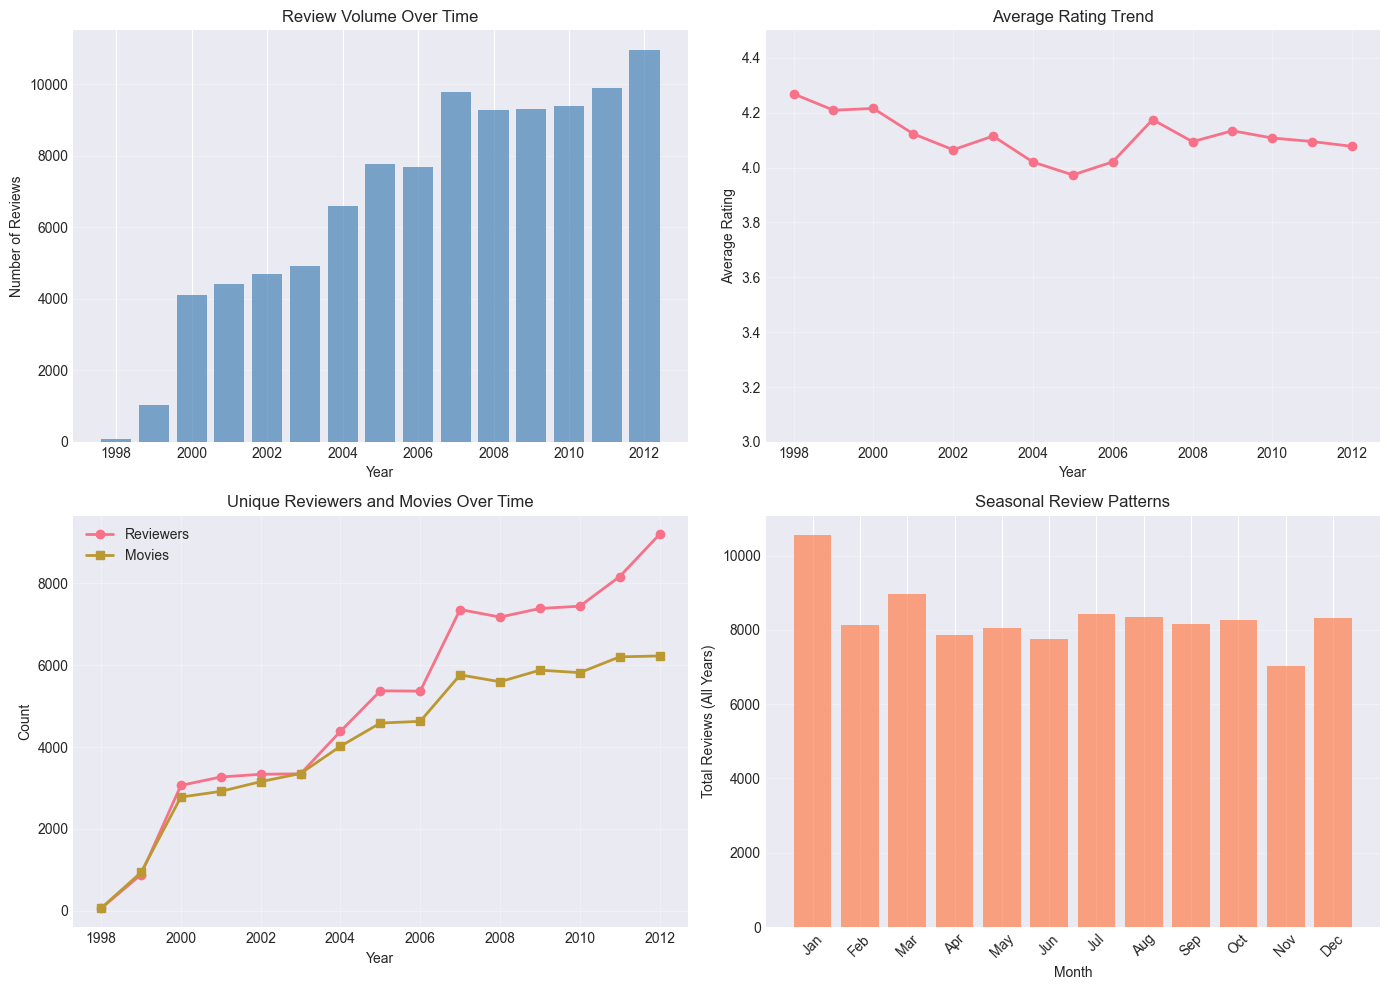


Temporal evolution plot saved to 'temporal_evolution.png'


In [5]:
# Visualize temporal trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Reviews by year
axes[0, 0].bar(yearly_stats.index, yearly_stats['Reviews'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Reviews')
axes[0, 0].set_title('Review Volume Over Time')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Average rating by year
axes[0, 1].plot(yearly_stats.index, yearly_stats['Avg Rating'], marker='o', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_title('Average Rating Trend')
axes[0, 1].set_ylim([3.0, 4.5])
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Unique users and movies by year
axes[1, 0].plot(yearly_stats.index, yearly_stats['Reviewers'], marker='o', label='Reviewers', linewidth=2)
axes[1, 0].plot(yearly_stats.index, yearly_stats['Movies'], marker='s', label='Movies', linewidth=2)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Unique Reviewers and Movies Over Time')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Monthly seasonality
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 1].bar(range(1, 13), monthly_stats['Total Reviews'], color='coral', alpha=0.7)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Reviews (All Years)')
axes[1, 1].set_title('Seasonal Review Patterns')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names, rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTemporal evolution plot saved to 'temporal_evolution.png'")

## 3. Network Construction

Building the bipartite network with reviewers and movies as two node types.

In [6]:
# Build bipartite network
print("=" * 70)
print("BUILDING BIPARTITE NETWORK")
print("=" * 70)

G = nx.Graph()

# Add nodes with bipartite labels
reviewers = df['review/userId'].unique()
movies = df['product/productId'].unique()

G.add_nodes_from(reviewers, bipartite=0)  # Reviewer nodes
G.add_nodes_from(movies, bipartite=1)     # Movie nodes

# Add edges
edges = [(row['review/userId'], row['product/productId']) for _, row in df.iterrows()]
G.add_edges_from(edges)

print(f"\nNetwork Statistics:")
print(f"  Total nodes: {G.number_of_nodes():,}")
print(f"  - Reviewer nodes: {len(reviewers):,}")
print(f"  - Movie nodes: {len(movies):,}")
print(f"  Total edges: {G.number_of_edges():,}")

# Calculate density
# For bipartite network: density = edges / (reviewers * movies)
max_edges = len(reviewers) * len(movies)
density = G.number_of_edges() / max_edges
print(f"  Network density: {density:.6f}")

# Average degree
avg_degree = 2 * G.number_of_edges() / G.number_of_nodes()
print(f"  Average degree: {avg_degree:.2f}")

BUILDING BIPARTITE NETWORK

Network Statistics:
  Total nodes: 92,263
  - Reviewer nodes: 66,556
  - Movie nodes: 25,707
  Total edges: 99,805
  Network density: 0.000058
  Average degree: 2.16


### Network Evolution by Time Period

In [7]:
# Build networks for each period
print("\n" + "=" * 70)
print("NETWORK METRICS BY TIME PERIOD")
print("=" * 70)

period_networks = {}
period_metrics = []

for period_name in ['Period 1 (1997-2001)', 'Period 2 (2002-2006)', 'Period 3 (2007-2012)']:
    period_df = df[df['period'] == period_name]
    
    # Build period network
    G_period = nx.Graph()
    period_reviewers = period_df['review/userId'].unique()
    period_movies = period_df['product/productId'].unique()
    
    G_period.add_nodes_from(period_reviewers, bipartite=0)
    G_period.add_nodes_from(period_movies, bipartite=1)
    
    period_edges = [(row['review/userId'], row['product/productId']) 
                    for _, row in period_df.iterrows()]
    G_period.add_edges_from(period_edges)
    
    period_networks[period_name] = G_period
    
    # Calculate metrics
    max_edges = len(period_reviewers) * len(period_movies)
    density = G_period.number_of_edges() / max_edges if max_edges > 0 else 0
    avg_degree = 2 * G_period.number_of_edges() / G_period.number_of_nodes() if G_period.number_of_nodes() > 0 else 0
    
    # Connected components
    components = list(nx.connected_components(G_period))
    num_components = len(components)
    largest_cc_size = len(max(components, key=len)) if components else 0
    
    period_metrics.append({
        'Period': period_name,
        'Nodes': G_period.number_of_nodes(),
        'Reviewers': len(period_reviewers),
        'Movies': len(period_movies),
        'Edges': G_period.number_of_edges(),
        'Density': f"{density:.6f}",
        'Avg Degree': f"{avg_degree:.2f}",
        'Components': num_components,
        'Largest CC': largest_cc_size
    })

period_metrics_df = pd.DataFrame(period_metrics)
print("\n", period_metrics_df.to_string(index=False))


NETWORK METRICS BY TIME PERIOD

               Period  Nodes  Reviewers  Movies  Edges  Density Avg Degree  Components  Largest CC
Period 1 (1997-2001)  12261       6924    5337   9627 0.000261       1.57        2922        4461
Period 2 (2002-2006)  31478      19266   12212  31621 0.000134       2.01        4673       19693
Period 3 (2007-2012)  62540      42852   19688  58562 0.000069       1.87        9515       35913


## 4. Connected Components Analysis

In [8]:
print("\n" + "=" * 70)
print("CONNECTED COMPONENTS ANALYSIS")
print("=" * 70)

# Get connected components
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"\nTotal number of components: {len(components)}")
print(f"Largest component size: {component_sizes[0]:,} nodes ({component_sizes[0]/G.number_of_nodes()*100:.1f}% of network)")

if len(component_sizes) > 1:
    print(f"Second largest component: {component_sizes[1]:,} nodes")
    print(f"\nTop 10 component sizes: {component_sizes[:10]}")

# Analyze largest connected component (LCC)
largest_cc = max(components, key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(f"\nLargest Connected Component (LCC):")
print(f"  Nodes: {G_lcc.number_of_nodes():,}")
print(f"  Edges: {G_lcc.number_of_edges():,}")

# Count reviewers and movies in LCC
lcc_reviewers = [n for n in G_lcc.nodes() if n in reviewers]
lcc_movies = [n for n in G_lcc.nodes() if n in movies]
print(f"  Reviewers: {len(lcc_reviewers):,}")
print(f"  Movies: {len(lcc_movies):,}")

# Distribution of component sizes
size_distribution = Counter(component_sizes)
print(f"\nComponent size distribution (size: count):")
for size in sorted(size_distribution.keys(), reverse=True)[:15]:
    print(f"  Size {size}: {size_distribution[size]} components")


CONNECTED COMPONENTS ANALYSIS

Total number of components: 10270
Largest component size: 64,037 nodes (69.4% of network)
Second largest component: 45 nodes

Top 10 component sizes: [64037, 45, 42, 39, 30, 28, 22, 21, 21, 20]

Largest Connected Component (LCC):
  Nodes: 64,037
  Edges: 81,837
  Reviewers: 49,307
  Movies: 14,730

Component size distribution (size: count):
  Size 64037: 1 components
  Size 45: 1 components
  Size 42: 1 components
  Size 39: 1 components
  Size 30: 1 components
  Size 28: 1 components
  Size 22: 1 components
  Size 21: 2 components
  Size 20: 4 components
  Size 19: 2 components
  Size 18: 4 components
  Size 17: 1 components
  Size 16: 4 components
  Size 15: 6 components
  Size 14: 7 components


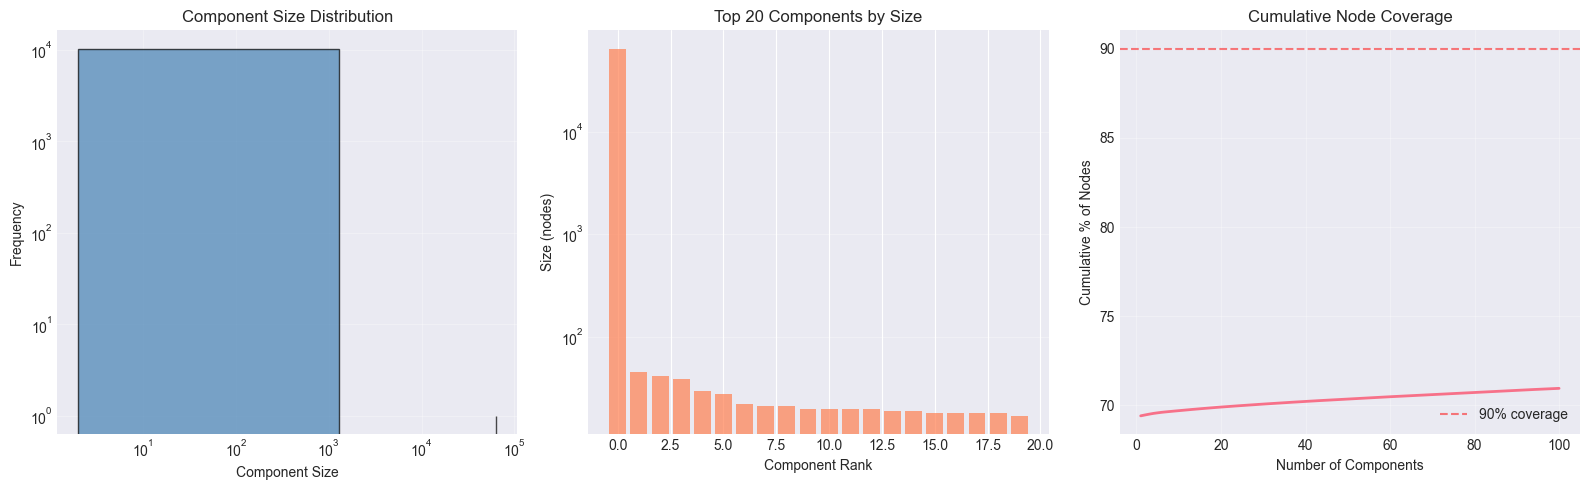


Component analysis plot saved to 'component_analysis.png'


In [9]:
# Visualize component analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Component size distribution (log scale)
axes[0].hist(component_sizes, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Component Size')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Component Size Distribution')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Top 20 component sizes
top_20_sizes = component_sizes[:20]
axes[1].bar(range(len(top_20_sizes)), top_20_sizes, color='coral', alpha=0.7)
axes[1].set_xlabel('Component Rank')
axes[1].set_ylabel('Size (nodes)')
axes[1].set_title('Top 20 Components by Size')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Cumulative node coverage
cumulative_nodes = np.cumsum(component_sizes)
cumulative_pct = cumulative_nodes / G.number_of_nodes() * 100
axes[2].plot(range(1, min(101, len(cumulative_pct)+1)), cumulative_pct[:100], linewidth=2)
axes[2].axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% coverage')
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Cumulative % of Nodes')
axes[2].set_title('Cumulative Node Coverage')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('component_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nComponent analysis plot saved to 'component_analysis.png'")

## 5. Degree and Centrality Analysis

Analyzing the most active reviewers and most reviewed movies.

In [10]:
print("\n" + "=" * 70)
print("DEGREE DISTRIBUTION ANALYSIS")
print("=" * 70)

# Calculate degrees
degrees = dict(G.degree())

# Separate reviewer and movie degrees
reviewer_degrees = {node: deg for node, deg in degrees.items() if node in reviewers}
movie_degrees = {node: deg for node, deg in degrees.items() if node in movies}

print(f"\nReviewer Degree Statistics:")
reviewer_deg_values = list(reviewer_degrees.values())
print(f"  Mean: {np.mean(reviewer_deg_values):.2f}")
print(f"  Median: {np.median(reviewer_deg_values):.0f}")
print(f"  Max: {np.max(reviewer_deg_values)}")
print(f"  Min: {np.min(reviewer_deg_values)}")

print(f"\nMovie Degree Statistics:")
movie_deg_values = list(movie_degrees.values())
print(f"  Mean: {np.mean(movie_deg_values):.2f}")
print(f"  Median: {np.median(movie_deg_values):.0f}")
print(f"  Max: {np.max(movie_deg_values)}")
print(f"  Min: {np.min(movie_deg_values)}")


DEGREE DISTRIBUTION ANALYSIS

Reviewer Degree Statistics:
  Mean: 1.50
  Median: 1
  Max: 143
  Min: 1

Movie Degree Statistics:
  Mean: 3.88
  Median: 2
  Max: 54
  Min: 1


In [11]:
# Top 20 most active reviewers
print("\n" + "=" * 70)
print("TOP 20 MOST ACTIVE REVIEWERS")
print("=" * 70)

top_reviewers = sorted(reviewer_degrees.items(), key=lambda x: x[1], reverse=True)[:20]

top_reviewer_stats = []
for rank, (reviewer_id, num_reviews) in enumerate(top_reviewers, 1):
    reviewer_reviews = df[df['review/userId'] == reviewer_id]
    avg_rating = reviewer_reviews['review/score'].mean()
    
    # Classify reviewer type
    if avg_rating <= 3.5:
        user_type = 'Critic'
    elif avg_rating < 4.0:
        user_type = 'Neutral'
    else:
        user_type = 'Enthusiast'
    
    top_reviewer_stats.append({
        'Rank': rank,
        'Reviewer ID': reviewer_id[:20] + '...' if len(reviewer_id) > 20 else reviewer_id,
        'Reviews': num_reviews,
        'Avg Rating': f"{avg_rating:.2f}",
        'Type': user_type
    })

top_reviewer_df = pd.DataFrame(top_reviewer_stats)
print("\n", top_reviewer_df.to_string(index=False))


TOP 20 MOST ACTIVE REVIEWERS

  Rank    Reviewer ID  Reviews Avg Rating       Type
    1 A3LZGLA88K0LA0      143       3.49     Critic
    2 A2NJO6YE954DBH      125       4.21 Enthusiast
    3 A16CZRQL23NOIW      125       4.67 Enthusiast
    4 A39CX0EE4BZCZC      119       4.14 Enthusiast
    5  ANCOMAI0I7LVG      117       3.91    Neutral
    6 A35ZK3M8L9JUPX      110       4.76 Enthusiast
    7 A10ODC971MDHV8      101       5.00 Enthusiast
    8 A2B73CL3QSYWLB       96       4.18 Enthusiast
    9  AJKWF4W7QD4NS       93       3.78    Neutral
   10  ABO2ZI2Y5DQ9T       93       3.10     Critic
   11   A1X054KUYG5V       90       3.60    Neutral
   12 A328S9RN3U5M68       89       4.16 Enthusiast
   13 A1D2C0WDCSHUWZ       88       3.96    Neutral
   14 A20EEWWSFMZ1PN       85       4.49 Enthusiast
   15 A19ZXK9HHVRV1X       83       2.93     Critic
   16 A1ER6IYOMM8VCT       81       3.71    Neutral
   17   AIMR915K4YCN       80       4.51 Enthusiast
   18 A2PV6GK1HV54Y9       78   

In [12]:
# User Type Analysis (for highly active users)
print("\n" + "=" * 70)
print("USER TYPE CLASSIFICATION (Reviewers with 50+ reviews)")
print("=" * 70)

# Get highly active reviewers
highly_active = {reviewer: deg for reviewer, deg in reviewer_degrees.items() if deg >= 50}

user_type_counts = {'Critic': 0, 'Neutral': 0, 'Enthusiast': 0}

for reviewer_id in highly_active.keys():
    avg_rating = df[df['review/userId'] == reviewer_id]['review/score'].mean()
    
    if avg_rating <= 3.5:
        user_type_counts['Critic'] += 1
    elif avg_rating < 4.0:
        user_type_counts['Neutral'] += 1
    else:
        user_type_counts['Enthusiast'] += 1

total_highly_active = sum(user_type_counts.values())
print(f"\nTotal highly active reviewers (50+ reviews): {total_highly_active}")
print(f"\nUser Type Distribution:")
for user_type, count in user_type_counts.items():
    pct = count / total_highly_active * 100 if total_highly_active > 0 else 0
    print(f"  {user_type}: {count} ({pct:.1f}%)")


USER TYPE CLASSIFICATION (Reviewers with 50+ reviews)

Total highly active reviewers (50+ reviews): 47

User Type Distribution:
  Critic: 7 (14.9%)
  Neutral: 19 (40.4%)
  Enthusiast: 21 (44.7%)


In [13]:
# Top 20 most reviewed movies
print("\n" + "=" * 70)
print("TOP 20 MOST REVIEWED MOVIES")
print("=" * 70)

top_movies = sorted(movie_degrees.items(), key=lambda x: x[1], reverse=True)[:20]

top_movie_stats = []
for rank, (movie_id, num_reviews) in enumerate(top_movies, 1):
    movie_reviews = df[df['product/productId'] == movie_id]
    avg_rating = movie_reviews['review/score'].mean()
    
    top_movie_stats.append({
        'Rank': rank,
        'Movie ID': movie_id[:30] + '...' if len(movie_id) > 30 else movie_id,
        'Reviews': num_reviews,
        'Avg Rating': f"{avg_rating:.2f}"
    })

top_movie_df = pd.DataFrame(top_movie_stats)
print("\n", top_movie_df.to_string(index=False))


TOP 20 MOST REVIEWED MOVIES

  Rank   Movie ID  Reviews Avg Rating
    1 B004OBQDJ8       54       4.33
    2 B000H7I6CU       53       4.62
    3 B004FM2ENU       53       4.58
    4 B000EBIP16       52       4.29
    5 B001G2MB2G       52       4.17
    6 B000ARIS52       51       4.04
    7 B008Y1RTUG       51       3.45
    8 B002LBKDYE       50       4.62
    9 B009NQKPUW       50       3.32
   10 B0013FBTHO       50       3.78
   11 B001K2KM8W       49       4.12
   12 B000M341QO       49       4.27
   13 B004WO6BPS       47       3.91
   14 B001FZ9AAU       46       4.52
   15 B00005JPA6       45       4.22
   16 B00005JPTK       45       4.04
   17 B001K2KM8M       45       4.42
   18 B0017XD3OY       45       3.53
   19 B002VRZEYM       44       4.66
   20 B001KZG99A       44       4.52


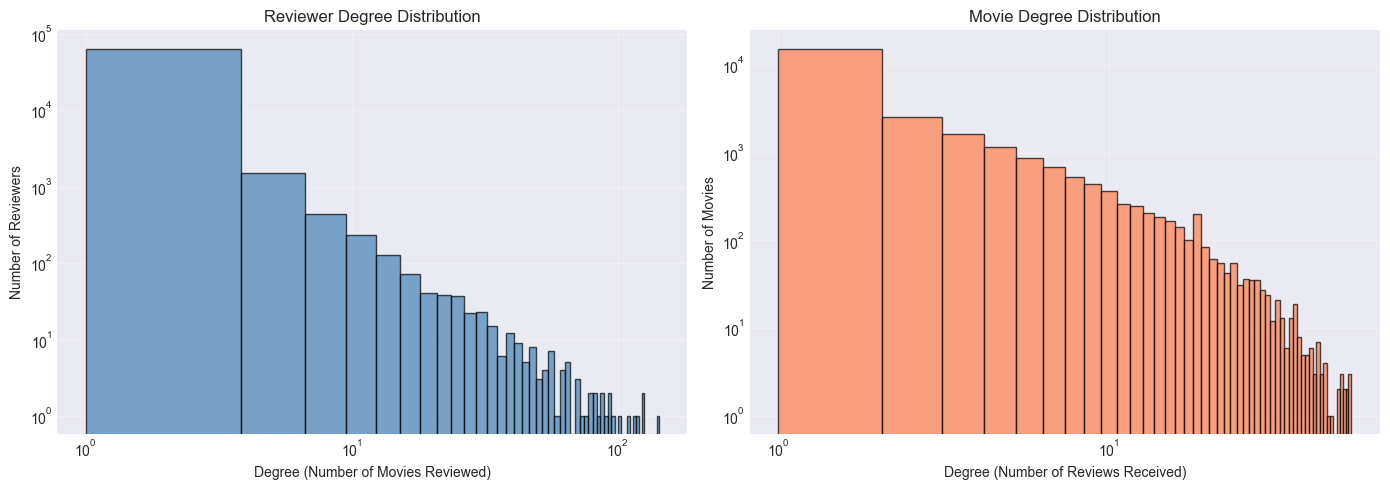


Degree distribution plot saved to 'degree_distribution.png'


In [14]:
# Degree distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviewer degree distribution
axes[0].hist(reviewer_deg_values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Degree (Number of Movies Reviewed)')
axes[0].set_ylabel('Number of Reviewers')
axes[0].set_title('Reviewer Degree Distribution')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Movie degree distribution
axes[1].hist(movie_deg_values, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Degree (Number of Reviews Received)')
axes[1].set_ylabel('Number of Movies')
axes[1].set_title('Movie Degree Distribution')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDegree distribution plot saved to 'degree_distribution.png'")

## 6. Taste Change Dynamics

Tracking how individual reviewers' rating behavior changed over time.

In [15]:
print("\n" + "=" * 70)
print("TASTE CHANGE ANALYSIS")
print("=" * 70)

# Find reviewers who appeared in multiple years
reviewer_years = df.groupby('review/userId')['year'].apply(lambda x: sorted(x.unique())).to_dict()
multi_year_reviewers = {reviewer: years for reviewer, years in reviewer_years.items() if len(years) > 1}

print(f"\nReviewers active in multiple years: {len(multi_year_reviewers):,}")
print(f"Total reviews from multi-year reviewers: {df[df['review/userId'].isin(multi_year_reviewers.keys())].shape[0]:,}")

# Calculate taste change
taste_changes = []

for reviewer_id, years in multi_year_reviewers.items():
    first_year = min(years)
    last_year = max(years)
    
    # Get reviews from first and last year
    first_year_reviews = df[(df['review/userId'] == reviewer_id) & (df['year'] == first_year)]
    last_year_reviews = df[(df['review/userId'] == reviewer_id) & (df['year'] == last_year)]
    
    # Calculate average ratings
    first_avg = first_year_reviews['review/score'].mean()
    last_avg = last_year_reviews['review/score'].mean()
    
    # Calculate change
    taste_change = last_avg - first_avg
    
    taste_changes.append({
        'reviewer_id': reviewer_id,
        'first_year': first_year,
        'last_year': last_year,
        'years_active': last_year - first_year,
        'first_avg': first_avg,
        'last_avg': last_avg,
        'taste_change': taste_change
    })

taste_df = pd.DataFrame(taste_changes)

# Statistics on taste change
print(f"\nTaste Change Statistics:")
print(f"  Mean change: {taste_df['taste_change'].mean():.3f}")
print(f"  Median change: {taste_df['taste_change'].median():.3f}")
print(f"  Std deviation: {taste_df['taste_change'].std():.3f}")

# Significant taste changes (>0.5 point difference)
significant_changes = taste_df[abs(taste_df['taste_change']) > 0.5]
print(f"\nReviewers with significant taste change (|Δ| > 0.5):")
print(f"  Count: {len(significant_changes):,}")
print(f"  Percentage: {len(significant_changes)/len(taste_df)*100:.1f}%")

# Direction of change
became_more_critical = len(taste_df[taste_df['taste_change'] < -0.5])
became_less_critical = len(taste_df[taste_df['taste_change'] > 0.5])

print(f"\nDirection of Significant Changes:")
print(f"  Became more critical (Δ < -0.5): {became_more_critical:,} ({became_more_critical/len(taste_df)*100:.1f}%)")
print(f"  Became less critical (Δ > 0.5): {became_less_critical:,} ({became_less_critical/len(taste_df)*100:.1f}%)")

# Show examples of large taste changes
print(f"\nTop 10 Largest Taste Increases (became less critical):")
top_increases = taste_df.nlargest(10, 'taste_change')[['first_year', 'last_year', 'first_avg', 'last_avg', 'taste_change']]
print(top_increases.to_string(index=False))

print(f"\nTop 10 Largest Taste Decreases (became more critical):")
top_decreases = taste_df.nsmallest(10, 'taste_change')[['first_year', 'last_year', 'first_avg', 'last_avg', 'taste_change']]
print(top_decreases.to_string(index=False))


TASTE CHANGE ANALYSIS

Reviewers active in multiple years: 5,401
Total reviews from multi-year reviewers: 30,796

Taste Change Statistics:
  Mean change: -0.142
  Median change: 0.000
  Std deviation: 1.470

Reviewers with significant taste change (|Δ| > 0.5):
  Count: 3,035
  Percentage: 56.2%

Direction of Significant Changes:
  Became more critical (Δ < -0.5): 1,705 (31.6%)
  Became less critical (Δ > 0.5): 1,330 (24.6%)

Top 10 Largest Taste Increases (became less critical):
 first_year  last_year  first_avg  last_avg  taste_change
       2005       2011        1.0       5.0           4.0
       2010       2012        1.0       5.0           4.0
       2008       2009        1.0       5.0           4.0
       2008       2012        1.0       5.0           4.0
       2000       2001        1.0       5.0           4.0
       2006       2007        1.0       5.0           4.0
       2004       2005        1.0       5.0           4.0
       2007       2008        1.0       5.0        

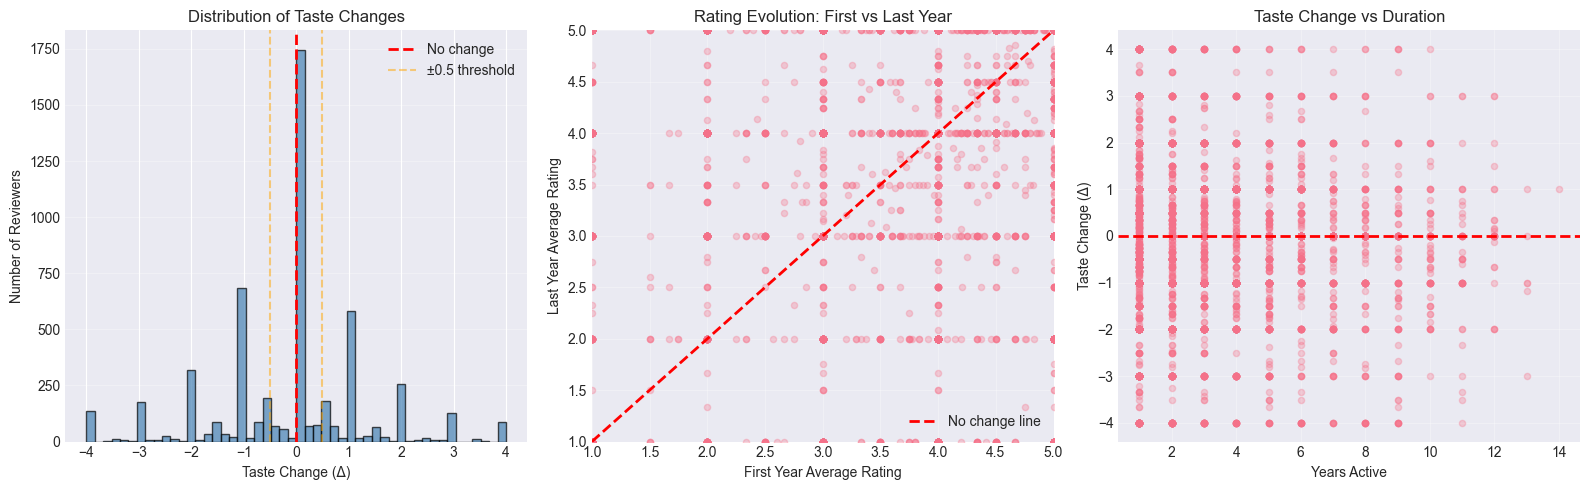


Taste change analysis plot saved to 'taste_change_analysis.png'


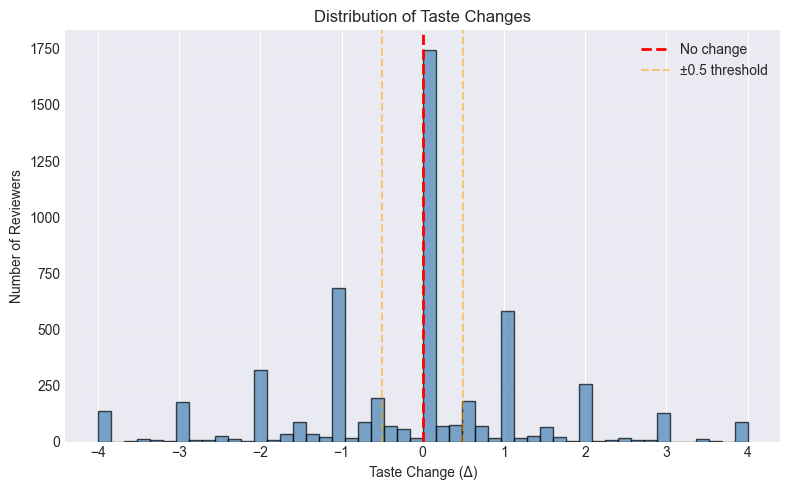

In [16]:
# Visualize taste changes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Distribution of taste changes
axes[0].hist(taste_df['taste_change'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0].axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='±0.5 threshold')
axes[0].axvline(x=-0.5, color='orange', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Taste Change (Δ)')
axes[0].set_ylabel('Number of Reviewers')
axes[0].set_title('Distribution of Taste Changes')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: First year vs last year average ratings
axes[1].scatter(taste_df['first_avg'], taste_df['last_avg'], alpha=0.3, s=20)
axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2, label='No change line')
axes[1].set_xlabel('First Year Average Rating')
axes[1].set_ylabel('Last Year Average Rating')
axes[1].set_title('Rating Evolution: First vs Last Year')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([1, 5])
axes[1].set_ylim([1, 5])

# Plot 3: Taste change by years active
axes[2].scatter(taste_df['years_active'], taste_df['taste_change'], alpha=0.3, s=20)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Years Active')
axes[2].set_ylabel('Taste Change (Δ)')
axes[2].set_title('Taste Change vs Duration')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('taste_change_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTaste change analysis plot saved to 'taste_change_analysis.png'")


# save plot 1 separately
plt.figure(figsize=(8, 5))
plt.hist(taste_df['taste_change'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='±0.5 threshold')
plt.axvline(x=-0.5, color='orange', linestyle='--', alpha=0.5)
plt.xlabel('Taste Change (Δ)')
plt.ylabel('Number of Reviewers')
plt.title('Distribution of Taste Changes')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('taste_change_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Community Structure Analysis

Detecting communities using the Louvain algorithm on the largest connected component.

In [17]:
print("\n" + "=" * 70)
print("COMMUNITY DETECTION (Louvain Algorithm)")
print("=" * 70)

# Import community detection (using python-louvain)
try:
    import community as community_louvain
    
    # Run Louvain on largest connected component
    partition = community_louvain.best_partition(G_lcc)
    modularity = community_louvain.modularity(partition, G_lcc)
    
    print(f"\nCommunity Detection Results:")
    print(f"  Modularity (Q): {modularity:.4f}")
    
    # Group nodes by community
    communities = defaultdict(list)
    for node, comm_id in partition.items():
        communities[comm_id].append(node)
    
    num_communities = len(communities)
    print(f"  Number of communities: {num_communities}")
    
    # Community size statistics
    community_sizes = sorted([len(nodes) for nodes in communities.values()], reverse=True)
    print(f"  Largest community: {community_sizes[0]} nodes")
    print(f"  Smallest community: {community_sizes[-1]} nodes")
    print(f"  Average community size: {np.mean(community_sizes):.1f}")
    print(f"  Median community size: {np.median(community_sizes):.0f}")
    
except ImportError:
    print("\nWarning: python-louvain package not installed.")
    print("Install with: pip install python-louvain")
    print("\nUsing alternative community detection...")
    
    # Alternative: use NetworkX's greedy modularity
    from networkx.algorithms import community as nx_community
    
    communities_gen = nx_community.greedy_modularity_communities(G_lcc)
    communities_list = list(communities_gen)
    
    # Create partition dict
    partition = {}
    for comm_id, comm_nodes in enumerate(communities_list):
        for node in comm_nodes:
            partition[node] = comm_id
    
    communities = {i: list(comm) for i, comm in enumerate(communities_list)}
    modularity = nx_community.modularity(G_lcc, communities_list)
    
    print(f"\nCommunity Detection Results (Greedy Modularity):")
    print(f"  Modularity (Q): {modularity:.4f}")
    
    num_communities = len(communities)
    print(f"  Number of communities: {num_communities}")
    
    community_sizes = sorted([len(nodes) for nodes in communities.values()], reverse=True)
    print(f"  Largest community: {community_sizes[0]} nodes")
    print(f"  Smallest community: {community_sizes[-1]} nodes")
    print(f"  Average community size: {np.mean(community_sizes):.1f}")
    print(f"  Median community size: {np.median(community_sizes):.0f}")


COMMUNITY DETECTION (Louvain Algorithm)

Community Detection Results:
  Modularity (Q): 0.8049
  Number of communities: 143
  Largest community: 1365 nodes
  Smallest community: 155 nodes
  Average community size: 447.8
  Median community size: 386


In [18]:
# Analyze community composition
print("\n" + "=" * 70)
print("COMMUNITY COMPOSITION ANALYSIS")
print("=" * 70)

community_profiles = []

for comm_id in sorted(communities.keys(), key=lambda x: len(communities[x]), reverse=True)[:15]:
    comm_nodes = communities[comm_id]
    
    # Separate reviewers and movies
    comm_reviewers = [n for n in comm_nodes if n in reviewers]
    comm_movies = [n for n in comm_nodes if n in movies]
    
    # Calculate internal edges
    subgraph = G_lcc.subgraph(comm_nodes)
    internal_edges = subgraph.number_of_edges()
    
    # Calculate density
    max_edges = len(comm_reviewers) * len(comm_movies) if len(comm_reviewers) > 0 and len(comm_movies) > 0 else 0
    density = internal_edges / max_edges if max_edges > 0 else 0
    
    community_profiles.append({
        'Community': comm_id + 1,
        'Size': len(comm_nodes),
        'Reviewers': len(comm_reviewers),
        'Movies': len(comm_movies),
        'Internal Edges': internal_edges,
        'Density': f"{density:.4f}",
        'Rev %': f"{len(comm_reviewers)/len(comm_nodes)*100:.1f}"
    })

comm_profile_df = pd.DataFrame(community_profiles)
print("\nTop 15 Communities by Size:")
print(comm_profile_df.to_string(index=False))


COMMUNITY COMPOSITION ANALYSIS

Top 15 Communities by Size:
 Community  Size  Reviewers  Movies  Internal Edges Density Rev %
        64  1365       1066     299            1500  0.0047  78.1
         4  1357        989     368            1503  0.0041  72.9
        60  1076        796     280            1151  0.0052  74.0
        18  1036        820     216            1118  0.0063  79.2
        47   882        615     267             957  0.0058  69.7
        95   877        635     242             927  0.0060  72.4
        22   852        629     223             900  0.0064  73.8
         3   824        592     232             880  0.0064  71.8
        81   801        603     198             847  0.0071  75.3
        34   793        597     196             864  0.0074  75.3
        80   766        605     161             811  0.0083  79.0
        92   738        529     209             782  0.0071  71.7
         1   737        524     213             756  0.0068  71.1
        97   73

In [19]:
# Identify specialized communities
print("\n" + "=" * 70)
print("SPECIALIZED COMMUNITY TYPES")
print("=" * 70)

# Reviewer-heavy communities
reviewer_heavy = comm_profile_df[comm_profile_df['Reviewers'].astype(int) > comm_profile_df['Movies'].astype(int)].head(5)
print("\nReviewer-Heavy Communities (more reviewers than movies):")
if len(reviewer_heavy) > 0:
    print(reviewer_heavy[['Community', 'Size', 'Reviewers', 'Movies', 'Rev %']].to_string(index=False))
else:
    print("  None found in top 15")

# Movie-heavy communities
movie_heavy = comm_profile_df[comm_profile_df['Movies'].astype(int) > comm_profile_df['Reviewers'].astype(int)].head(5)
print("\nMovie-Heavy Communities (more movies than reviewers):")
if len(movie_heavy) > 0:
    print(movie_heavy[['Community', 'Size', 'Reviewers', 'Movies', 'Rev %']].to_string(index=False))
else:
    print("  None found in top 15")

# High-density communities
comm_profile_df['Density_num'] = comm_profile_df['Density'].astype(float)
high_density = comm_profile_df.nlargest(5, 'Density_num')
print("\nHigh-Density Communities (tight-knit groups):")
print(high_density[['Community', 'Size', 'Density', 'Reviewers', 'Movies']].to_string(index=False))


SPECIALIZED COMMUNITY TYPES

Reviewer-Heavy Communities (more reviewers than movies):
 Community  Size  Reviewers  Movies Rev %
        64  1365       1066     299  78.1
         4  1357        989     368  72.9
        60  1076        796     280  74.0
        18  1036        820     216  79.2
        47   882        615     267  69.7

Movie-Heavy Communities (more movies than reviewers):
  None found in top 15

High-Density Communities (tight-knit groups):
 Community  Size Density  Reviewers  Movies
        80   766  0.0083        605     161
        13   714  0.0080        543     171
        97   736  0.0077        559     177
        34   793  0.0074        597     196
        81   801  0.0071        603     198


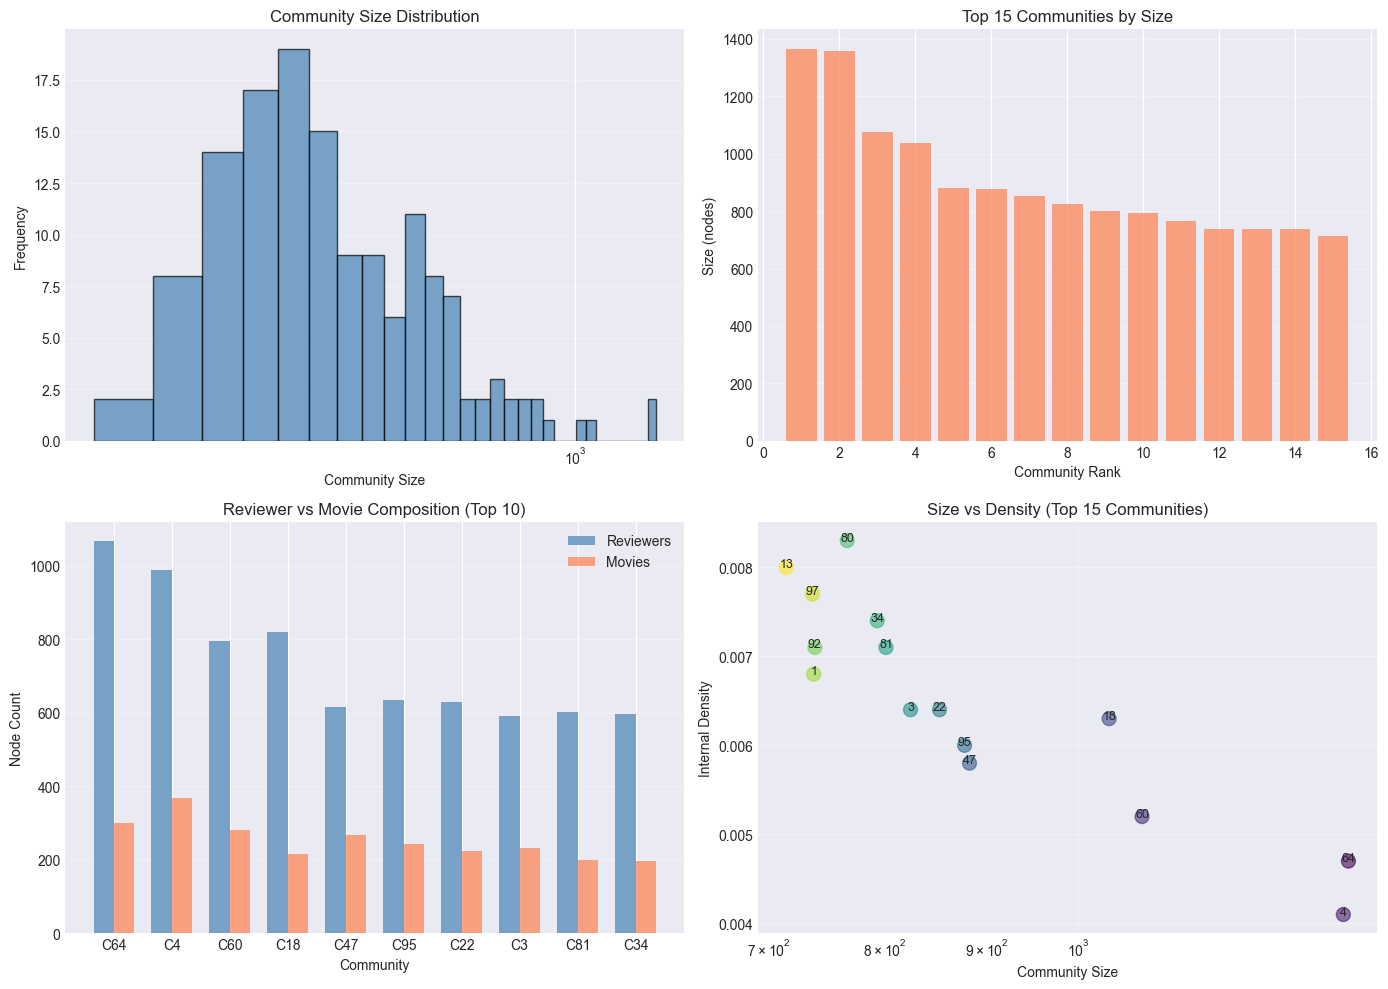


Community structure plot saved to 'community_structure.png'


In [20]:
# Visualize community structure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Community size distribution
axes[0, 0].hist(community_sizes, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Community Size')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Community Size Distribution')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Top communities by size
top_15_sizes = community_sizes[:15]
axes[0, 1].bar(range(1, len(top_15_sizes)+1), top_15_sizes, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Community Rank')
axes[0, 1].set_ylabel('Size (nodes)')
axes[0, 1].set_title('Top 15 Communities by Size')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Reviewer/Movie composition in top communities
comm_ids = comm_profile_df['Community'].head(10).values
reviewer_counts = comm_profile_df['Reviewers'].head(10).values
movie_counts = comm_profile_df['Movies'].head(10).values

x = np.arange(len(comm_ids))
width = 0.35

axes[1, 0].bar(x - width/2, reviewer_counts, width, label='Reviewers', color='steelblue', alpha=0.7)
axes[1, 0].bar(x + width/2, movie_counts, width, label='Movies', color='coral', alpha=0.7)
axes[1, 0].set_xlabel('Community')
axes[1, 0].set_ylabel('Node Count')
axes[1, 0].set_title('Reviewer vs Movie Composition (Top 10)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f"C{i}" for i in comm_ids])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Size vs Density scatter
sizes = comm_profile_df['Size'].head(15).values
densities = comm_profile_df['Density_num'].head(15).values

axes[1, 1].scatter(sizes, densities, s=100, alpha=0.6, c=range(len(sizes)), cmap='viridis')
for i, comm_id in enumerate(comm_profile_df['Community'].head(15)):
    axes[1, 1].annotate(f"{comm_id}", (sizes[i], densities[i]), fontsize=9, ha='center')
axes[1, 1].set_xlabel('Community Size')
axes[1, 1].set_ylabel('Internal Density')
axes[1, 1].set_title('Size vs Density (Top 15 Communities)')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('community_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCommunity structure plot saved to 'community_structure.png'")